## MICRON Technologies Analysis

### Profile
Micron Technology, Inc. designs, develops, manufactures, and sells memory and storage products in the United States, Taiwan, Mainland China, rest of the Asia Pacific, Hong Kong, Japan, Europe, and internationally. The company operates through four segments: Compute and Networking Business Unit, Mobile Business Unit, Embedded Business Unit, and Storage Business Unit. It provides memory and storage technologies comprising dynamic random access memory semiconductor devices with low latency that provide high-speed data retrieval; non-volatile and re-writeable semiconductor storage devices; and non-volatile re-writable semiconductor memory devices that provide fast read speeds under the Micron and Crucial brands, as well as through private labels. The company offers serves the data center, PC, graphics, networking, automotive, industrial, and consumer embedded markets, as well as for smartphone and other mobile-device markets. It markets its products through its direct sales force, independent sales representatives, distributors, and retailers; and web-based customer direct sales channel, as well as through channel and distribution partners. Micron Technology, Inc. was founded in 1978 and is headquartered in Boise, Idaho.

### Risk Factors (Ranked Highest to Lowest)
1. **Cyclicality of the Semiconductor Industry**
   - Revenue and profitability are highly sensitive to changes in supply/demand, pricing, and macroeconomic trends.

2. **Rapid Technological Change**
   - Constant innovation is required to avoid product obsolescence and loss of market share.

3. **Significant Capital Investment Requirements**
   - High fixed costs for fabrication plants and R&D increase downside risk in demand downturns.

4. **Geopolitical and Trade Risks**
   - Exposure to export restrictions, especially with China, poses strategic and operational risks.

5. **Customer Concentration**
   - A small number of customers contribute a large portion of revenue, increasing financial dependency.

6. **Intellectual Property Litigation**
   - Exposure to lawsuits and patent claims can lead to financial penalties or business disruption.

7. **Environmental and Regulatory Compliance**
   - Must adhere to international environmental and safety regulations, adding operational complexity.

8. **Supply Chain Disruption**
   - Delays in sourcing materials or equipment can halt production and affect delivery timelines.

---

## Revenue Streams (Ranked: Largest to Smallest)

1. **DRAM (Dynamic Random-Access Memory)**
   - Largest segment; used in data centers, PCs, and mobile devices.

2. **NAND Flash Memory**
   - Critical for SSDs, smartphones, and high-performance storage.

3. **Embedded and Specialty Solutions**
   - Includes NOR Flash and products for automotive and industrial applications.

4. **3D XPoint (Legacy/Phased Out)**
   - Previously strategic, now deprioritized with minimal ongoing contribution.

5. **Licensing and Other Revenue**
   - Smallest stream; includes intellectual property licensing and minor service revenues.

---

> **Note**: Rankings are based on qualitative risk severity and disclosed product revenue shares in the prospectus. Subject to change based on market shifts and operational strategy.


In [79]:
from datetime import datetime, date
import requests
import pandas as pd
from dateutil import parser
import numpy as np
import csv
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import yfinance as yf
import statsmodels.api as sm

In [10]:
# List of URLs to scrape
df_earnings = pd.read_csv("MU/MU_Earnings_sheet1.csv")
df_earnings.head()

,Symbol,Company,Earnings Date,EPS Estimate,Reported EPS,Surprise (%)
0,MU,Micron Technology Inc,"March 18, 2026 at 6 AM EDT",-,-,-
1,MU,Micron Technology Inc,"December 16, 2025 at 6 PM EST",-,-,-
2,MU,Micron Technology Inc,"September 23, 2025 at 4 PM EDT",-,-,-
3,MU,Micron Technology Inc,"June 25, 2025 at 6 PM EDT",-,-,-
4,MU,"Micron Technology, Inc.","March 20, 2025 at 4 PM EDT",1.42,1.56,9.59


In [21]:
# convert the EPS columns to decimal and the earnings datee column to date
# eps_columns = [x for x in df_earnings.columns if "EPS" in x or x == "Surprise (%)"]
# for eps_col in eps_columns:
#     df_earnings[eps_col] = pd.to_numeric(df_earnings[eps_col], errors='coerce', downcast='float')
df_earnings['Date'] = df_earnings["Earnings Date"].apply(lambda x: parser.parse(x))
df_earnings['Date'] = df_earnings["Date"].dt.date
df_earnings.head()

,Symbol,Company,Earnings Date,EPS Estimate,Reported EPS,Surprise (%),Date
0,MU,Micron Technology Inc,"March 18, 2026 at 6 AM EDT",NaN,NaN,NaN,2026-03-18
1,MU,Micron Technology Inc,"December 16, 2025 at 6 PM EST",NaN,NaN,NaN,2025-12-16
2,MU,Micron Technology Inc,"September 23, 2025 at 4 PM EDT",NaN,NaN,NaN,2025-09-23
3,MU,Micron Technology Inc,"June 25, 2025 at 6 PM EDT",NaN,NaN,NaN,2025-06-25
4,MU,"Micron Technology, Inc.","March 20, 2025 at 4 PM EDT",1.42,1.56,9.59,2025-03-20


(array([ 6574.,  8035.,  9496., 10957., 12418., 13879., 15340., 16801.,
        18262., 19723., 21184.]),
 [Text(6574.0, 0, '1988'),
  Text(8035.0, 0, '1992'),
  Text(9496.0, 0, '1996'),
  Text(10957.0, 0, '2000'),
  Text(12418.0, 0, '2004'),
  Text(13879.0, 0, '2008'),
  Text(15340.0, 0, '2012'),
  Text(16801.0, 0, '2016'),
  Text(18262.0, 0, '2020'),
  Text(19723.0, 0, '2024'),
  Text(21184.0, 0, '2028')])

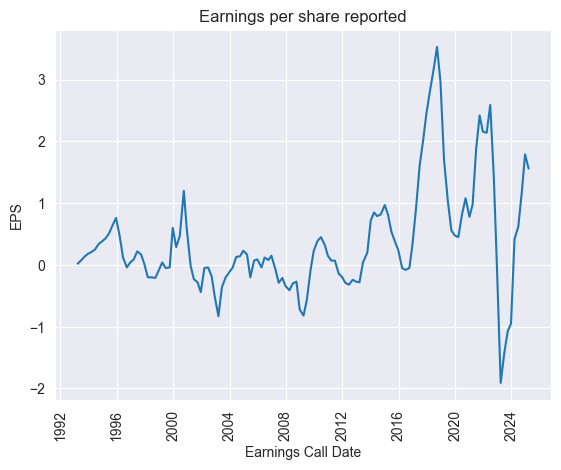

In [22]:
# plot the eps
df_earnings.sort_values(by=['Date'], ascending=True, inplace=True)
sns.lineplot(df_earnings, x="Date", y="Reported EPS").set_title("Earnings per share reported")
plt.xlabel("Earnings Call Date")
plt.ylabel("EPS")
plt.xticks(rotation=90)

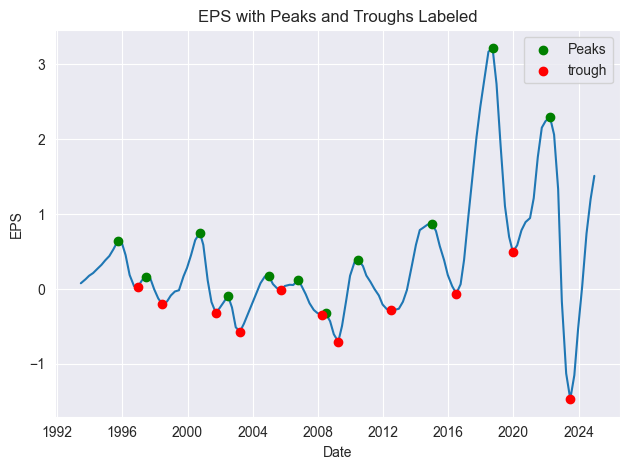

In [48]:
# smooth the data first
# df_earnings.reset_index(inplace=True, drop=True)
# df_earnings['EPS_smoothed'] = df_earnings['Reported EPS'].rolling(window=3, center=True).mean()
# find the peaks
peaks, _ = find_peaks(df_earnings['EPS_smoothed'], distance=4)
# Find troughs (local minima)
vals = df_earnings['EPS_smoothed'].to_numpy()
trough, _ = find_peaks(-vals, distance=4)
df_earnings['peak'] = df_earnings.index.isin(peaks).astype(int)
df_earnings['trough'] = df_earnings.index.isin(trough).astype(int)

def peak_trough_label(peak_val, trough_val):
    if peak_val == 1:
        return "peak"
    elif trough_val == 1:
        return "trough"
    else:
        return "None"

df_earnings['peak_trough_label'] = df_earnings[['peak', 'trough']].apply(lambda x: peak_trough_label(x['peak'], x['trough']), axis=1)
# plot the smoothed eps
sns.lineplot(df_earnings, x="Date", y="EPS_smoothed").set_title("EPS smoothed")
plt.scatter(df_earnings["Date"].iloc[peaks], df_earnings['EPS_smoothed'].iloc[peaks], color='green', label='Peaks', zorder=5)
plt.scatter(df_earnings["Date"].iloc[trough], df_earnings['EPS_smoothed'].iloc[trough], color='red', label='trough', zorder=5)
plt.title("EPS with Peaks and Troughs Labeled")
plt.xlabel("Date")
plt.ylabel("EPS")
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
# Get the number of buisness days between the peaks
df_peaks = df_earnings[df_earnings["peak_trough_label"].isin(["peak", "trough"])]
df_peaks.reset_index(inplace=True)
# Months difference between consecutive rows
def months_between(d1, d2):
    return (d2.year - d1.year) * 12 + (d2.month - d1.month)
# Compute business day difference between consecutive dates
df_peaks['months_between'] = [
    months_between(df_peaks['Date'][i - 1], df_peaks['Date'][i]) if i > 0 else None
    for i in range(len(df_peaks))
]

df_peaks

/var/folders/j5/d8d1mkwd55q6sz79ygcfg1rr0000gn/T/ipykernel_79096/1096086866.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_peaks['months_between'] = [


,index,Symbol,Company,Earnings Date,EPS Estimate,Reported EPS,Surprise (%),Date,EPS_smoothed,peak,trough,peak_trough_label,months_between
0,10,MU,"Micron Technology, Inc.","September 21, 1995 at 12 AM EDT",0.60,0.65,7.890000,1995-09-21,0.640000,1,0,peak,NaN
1,15,MU,"Micron Technology, Inc.","December 16, 1996 at 12 AM EST",0.03,0.04,30.500000,1996-12-16,0.030000,0,1,trough,15.0
2,17,MU,"Micron Technology, Inc.","June 16, 1997 at 12 AM EDT",0.18,0.22,19.420000,1997-06-16,0.160000,1,0,peak,6.0
3,21,MU,"Micron Technology, Inc.","June 18, 1998 at 12 AM EDT",-0.22,-0.20,5.160000,1998-06-18,-0.203333,0,1,trough,12.0
4,30,MU,"Micron Technology, Inc.","October 4, 2000 at 12 AM EDT",0.96,1.20,24.650000,2000-10-04,0.750000,1,0,peak,28.0
5,34,MU,"Micron Technology, Inc.","September 25, 2001 at 12 AM EDT",-0.34,-0.28,17.820000,2001-09-25,-0.316667,0,1,trough,11.0
6,37,MU,"Micron Technology, Inc.","June 25, 2002 at 12 AM EDT",0.06,-0.04,-168.970001,2002-06-25,-0.090000,1,0,peak,9.0
7,40,MU,"Micron Technology, Inc.","March 20, 2003 at 12 AM EST",-0.46,-0.83,-78.879997,2003-03-20,-0.570000,0,1,trough,9.0
8,47,MU,"Micron Technology, Inc.","December 22, 2004 at 12 AM EST",0.22,0.23,6.650000,2004-12-22,0.180000,1,0,peak,21.0
9,50,MU,"Micron Technology, Inc.","September 29, 2005 at 12 AM EDT",-0.08,0.07,183.520004,2005-09-29,-0.013333,0,1,trough,9.0


<Axes: xlabel='peak_trough_label', ylabel='months_between'>

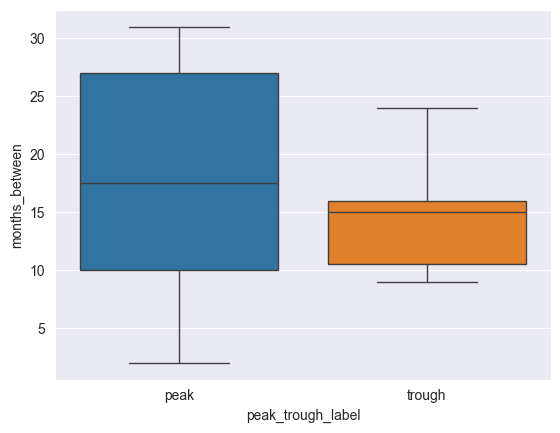

In [68]:
sns.boxplot(df_peaks, x="peak_trough_label", y='months_between', hue="peak_trough_label")

In [56]:
# get the daily stock prices
cosumer_tickers = ["MU"]
dfs = []
for ticker in cosumer_tickers:
    df_tmp = yf.Ticker(ticker)
    # Download historical price data
    historical_data = df_tmp.history(period="max", interval="1d")
    historical_data['ticker'] = ticker
    # Display the first few rows
    dfs.append(historical_data)

MU = dfs[0]
MU

,Open,High,Low,Close,Volume,Dividends,Stock Splits,ticker
Date,,,,,,,,
1984-06-01 00:00:00-04:00,0.000000,1.366172,1.354188,1.354188,7340000,0.0,0.0,MU
1984-06-04 00:00:00-04:00,0.000000,1.366172,1.354188,1.354188,4067000,0.0,0.0,MU
1984-06-05 00:00:00-04:00,0.000000,1.354189,1.342205,1.342205,2089000,0.0,0.0,MU
1984-06-06 00:00:00-04:00,0.000000,1.438076,1.414108,1.414108,1894000,0.0,0.0,MU
1984-06-07 00:00:00-04:00,0.000000,1.581883,1.569900,1.569900,2078000,0.0,0.0,MU
...,...,...,...,...,...,...,...,...
2025-06-02 00:00:00-04:00,94.580002,99.239998,94.400002,98.180000,16850300,0.0,0.0,MU
2025-06-03 00:00:00-04:00,98.360001,102.930000,96.959999,102.250000,22757600,0.0,0.0,MU
2025-06-04 00:00:00-04:00,102.379997,103.910004,101.699997,103.250000,14595900,0.0,0.0,MU


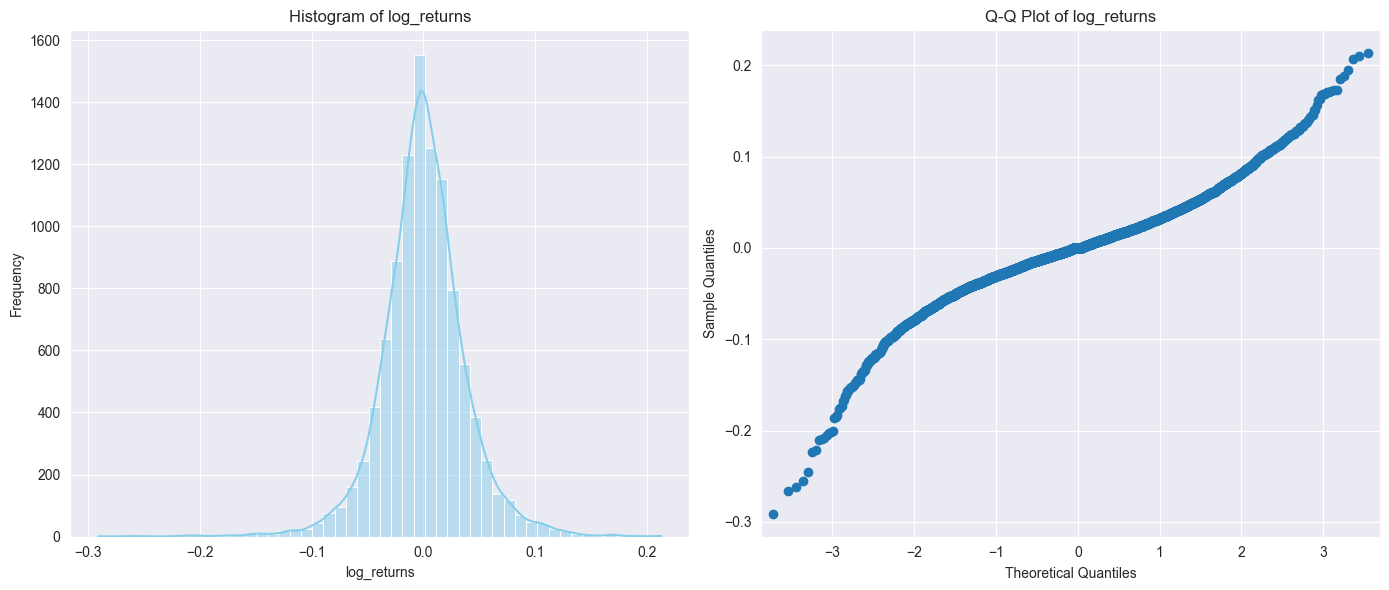

In [57]:
# Calculate the log returns
MU["log_returns"] = np.log(MU["Close"]) - np.log(MU["Close"].shift(1))
# plot the distribution of the log returns
# Histogram of log returns
def plot_distribution(df, column: str):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.histplot(df, x=column, bins=50, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Histogram of {column}')
    axes[0].set_xlabel(f'{column}')
    axes[0].set_ylabel('Frequency')

    # Q-Q plot
    sm.qqplot(df[column], line='s', ax=axes[1])
    axes[1].set_title(f'Q-Q Plot of {column}')

    plt.tight_layout()
    plt.show()


plot_distribution(df=MU, column="log_returns")

In [64]:
# calcualte the proportion of positive returns between each earnings call
MU["Regime"] = MU["log_returns"].apply(lambda x: 0 if x <= 0 else 1)

proportion_vals = []
counter = 0
for earnings_date in df_earnings["Date"]:
    earnings_date = pd.to_datetime(earnings_date).tz_localize('America/New_York')
    if counter == 0:
        # convert date to datetime
        previous_date = earnings_date
        proportion_vals.append(np.nan)
        counter += 1
        continue
    else:
        # filter the AOUT data between previous_date and earnings_date
        count_df = MU[(MU.index >= previous_date) & (MU.index < earnings_date)]["Regime"].value_counts()
        sum_df = count_df.sum()
        prop_val_df = count_df / sum_df
        if prop_val_df.shape[0] == 2:
            prop_val = float(prop_val_df[prop_val_df.index == 1].values[0])
        elif prop_val_df.shape[0] == 0:
            prop_val = None
        else:
            if prop_val_df.index[0] == 1:
                prop_val = float(prop_val_df.values[0])
            else:
                prop_val = 1 - float(prop_val_df.values[0])
        proportion_vals.append(prop_val)
        previous_date = earnings_date
        counter += 1


MU["vol_schock"] = MU["log_returns"].apply(lambda x: 1 if x >= 0.05 else 0)
MU["vol_schock_neg"] = MU["log_returns"].apply(lambda x: 1 if x <= -0.05 else 0)

neg_shocks = []
pos_shocks = []
counter = 0
for earnings_date in df_earnings["Date"]:
    earnings_date = pd.to_datetime(earnings_date).tz_localize('America/New_York')
    if counter == 0:
        previous_date = earnings_date
        neg_shocks.append(np.nan)
        pos_shocks.append(np.nan)
        counter += 1
        continue
    else:
        pos_val = MU[(MU.index >= previous_date) & (MU.index < earnings_date)]["vol_schock"].sum()
        neg_val = MU[(MU.index >= previous_date) & (MU.index < earnings_date)]["vol_schock_neg"].sum()
        neg_shocks.append(neg_val)
        pos_shocks.append(pos_val)
        previous_date = earnings_date
        counter += 1

# df_earnings["Regime"] = proportion_vals
df_earnings["neg_shocks"] = neg_shocks
df_earnings["pos_shocks"] = pos_shocks
df_earnings["proportion"] = proportion_vals
df_earnings

,Symbol,Company,Earnings Date,EPS Estimate,Reported EPS,Surprise (%),Date,EPS_smoothed,peak,trough,peak_trough_label,neg_shocks,pos_shocks,proportion
0,MU,"Micron Technology, Inc.","March 26, 1993 at 12 AM EST",0.02,0.02,2.660000,1993-03-26,NaN,0,0,None,NaN,NaN,NaN
1,MU,"Micron Technology, Inc.","June 15, 1993 at 12 AM EDT",0.04,0.07,76.970001,1993-06-15,0.076667,0,0,None,1.0,2.0,0.527273
2,MU,"Micron Technology, Inc.","September 28, 1993 at 12 AM EDT",0.12,0.14,20.420000,1993-09-28,0.130000,0,0,None,1.0,5.0,0.630137
3,MU,"Micron Technology, Inc.","December 17, 1993 at 12 AM EST",0.15,0.18,19.410000,1993-12-17,0.176667,0,0,None,9.0,2.0,0.473684
4,MU,"Micron Technology, Inc.","March 18, 1994 at 12 AM EST",0.19,0.21,11.250000,1994-03-18,0.213333,0,0,None,1.0,4.0,0.603175
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,MU,"Micron Technology, Inc.","March 20, 2025 at 4 PM EDT",1.42,1.56,9.590000,2025-03-20,NaN,0,0,None,5.0,5.0,0.475410
129,MU,Micron Technology Inc,"June 25, 2025 at 6 PM EDT",NaN,NaN,NaN,2025-06-25,NaN,0,0,None,4.0,5.0,0.545455
130,MU,Micron Technology Inc,"September 23, 2025 at 4 PM EDT",NaN,NaN,NaN,2025-09-23,NaN,0,0,None,0.0,0.0,NaN
131,MU,Micron Technology Inc,"December 16, 2025 at 6 PM EST",NaN,NaN,NaN,2025-12-16,NaN,0,0,None,0.0,0.0,NaN


<Axes: xlabel='Date', ylabel='proportion'>

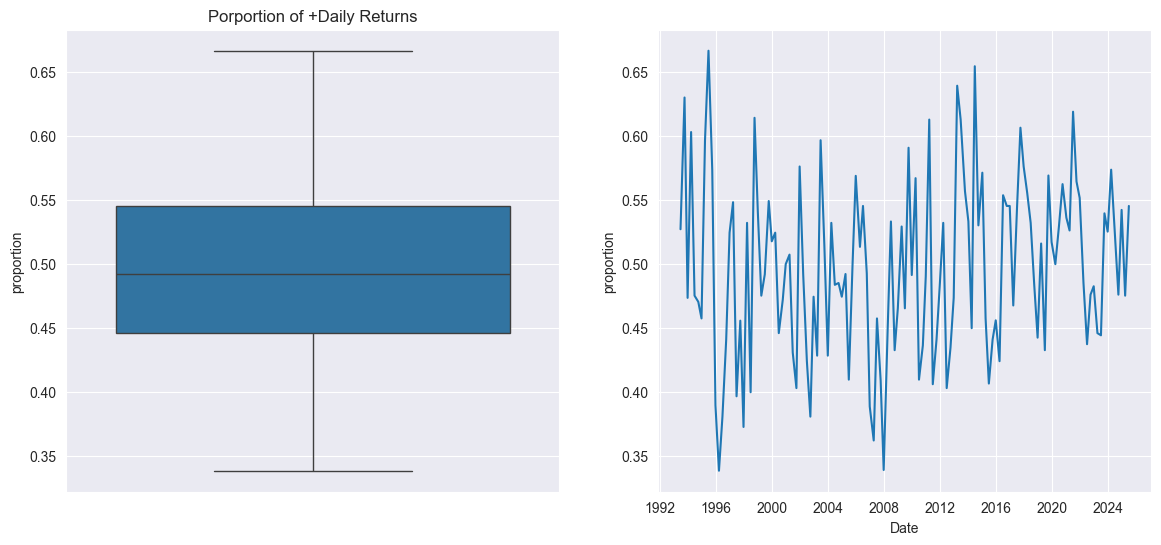

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(df_earnings["proportion"], ax=axes[0]).set_title("Porportion of +Daily Returns")
sns.lineplot(df_earnings, x='Date', y='proportion', ax=axes[1])

In [72]:
# merge the closing price with earnings
MU = MU.reset_index()
MU['Day'] = MU["Date"].dt.date

df_earningsII = df_earnings.merge(MU[["Day", "Close"]], left_on="Date", right_on="Day", how="left")
# calcaulte the log returns of the closing price
df_earningsII['log_returns'] = np.log(df_earningsII["Close"]) - np.log(df_earningsII["Close"].shift(1))
df_earningsII

,Symbol,Company,Earnings Date,EPS Estimate,Reported EPS,Surprise (%),Date,EPS_smoothed,peak,trough,peak_trough_label,neg_shocks,pos_shocks,proportion,Day,Close,log_returns
0,MU,"Micron Technology, Inc.","March 26, 1993 at 12 AM EST",0.02,0.02,2.660000,1993-03-26,NaN,0,0,None,NaN,NaN,NaN,1993-03-26,2.340416,NaN
1,MU,"Micron Technology, Inc.","June 15, 1993 at 12 AM EDT",0.04,0.07,76.970001,1993-06-15,0.076667,0,0,None,1.0,2.0,0.527273,1993-06-15,3.353793,0.359763
2,MU,"Micron Technology, Inc.","September 28, 1993 at 12 AM EDT",0.12,0.14,20.420000,1993-09-28,0.130000,0,0,None,1.0,5.0,0.630137,1993-09-28,5.766594,0.541990
3,MU,"Micron Technology, Inc.","December 17, 1993 at 12 AM EST",0.15,0.18,19.410000,1993-12-17,0.176667,0,0,None,9.0,2.0,0.473684,1993-12-17,4.468632,-0.254999
4,MU,"Micron Technology, Inc.","March 18, 1994 at 12 AM EST",0.19,0.21,11.250000,1994-03-18,0.213333,0,0,None,1.0,4.0,0.603175,1994-03-18,8.550790,0.648941
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,MU,"Micron Technology, Inc.","March 20, 2025 at 4 PM EDT",1.42,1.56,9.590000,2025-03-20,NaN,0,0,None,5.0,5.0,0.475410,2025-03-20,102.866066,-0.007402
129,MU,Micron Technology Inc,"June 25, 2025 at 6 PM EDT",NaN,NaN,NaN,2025-06-25,NaN,0,0,None,4.0,5.0,0.545455,NaN,NaN,NaN
130,MU,Micron Technology Inc,"September 23, 2025 at 4 PM EDT",NaN,NaN,NaN,2025-09-23,NaN,0,0,None,0.0,0.0,NaN,NaN,NaN,NaN
131,MU,Micron Technology Inc,"December 16, 2025 at 6 PM EST",NaN,NaN,NaN,2025-12-16,NaN,0,0,None,0.0,0.0,NaN,NaN,NaN,NaN


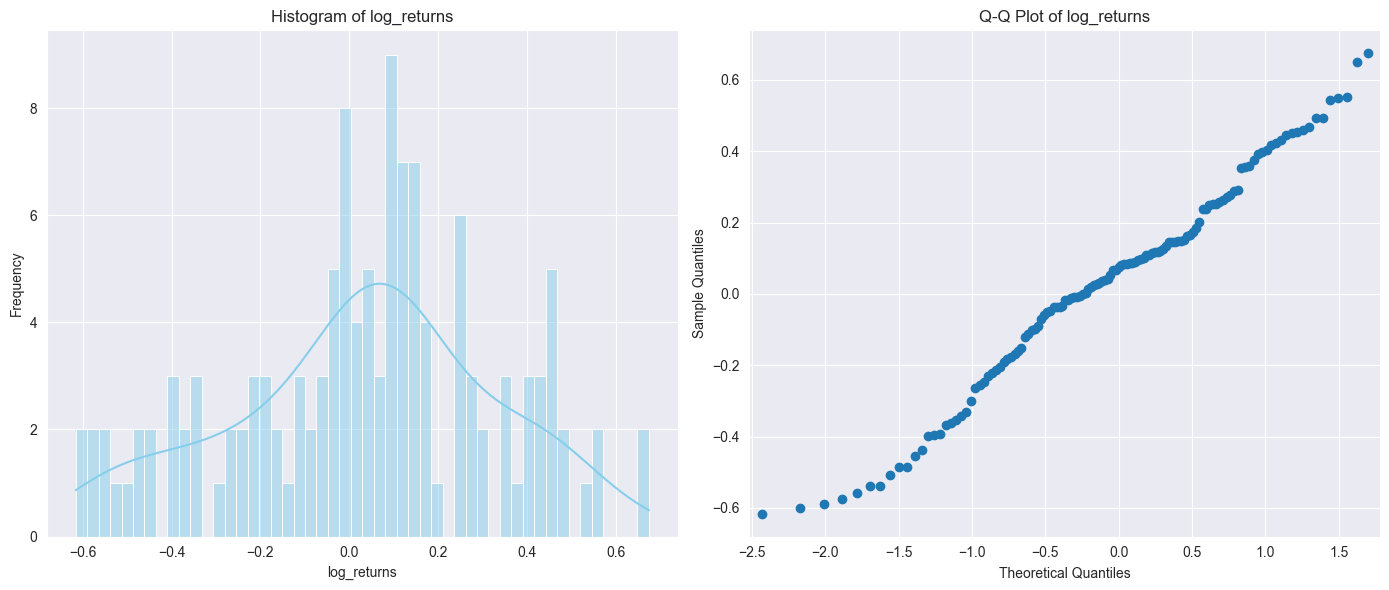

In [73]:
plot_distribution(df=df_earningsII, column="log_returns")

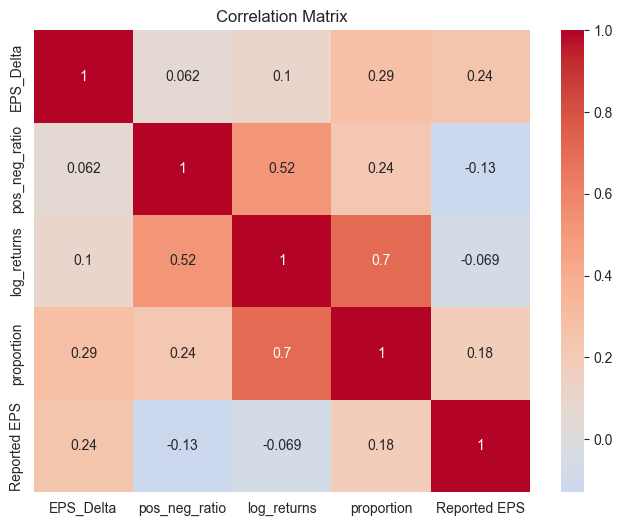

In [76]:
# Calaculate the delta for the reported eps
# df_earningsII['EPS_Delta'] = df_earnings['Reported EPS'].diff()
# # calculate the ratio between positive and negative shocks
# df_earningsII["pos_neg_ratio"] = df_earnings["pos_shocks"] / df_earnings["neg_shocks"]

# plot the correlation plot
corr = df_earningsII[[
    "EPS_Delta", "pos_neg_ratio", "log_returns", "proportion", "Reported EPS"
]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

<Axes: xlabel='Date', ylabel='value'>

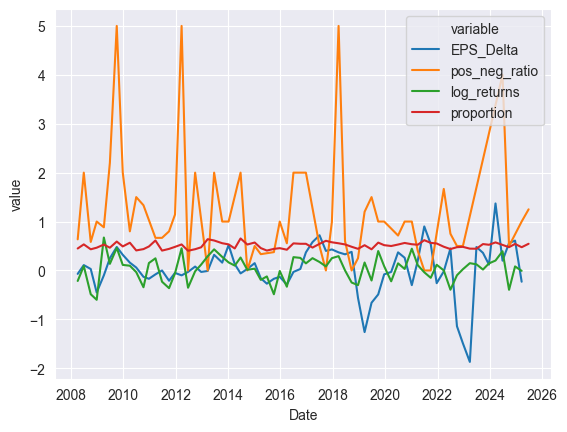

In [80]:
# df_plot_line = df_earningsII[[
#     "Date", "EPS_Delta", "pos_neg_ratio", "log_returns", "proportion", "Reported EPS"
# ]].melt(id_vars=["Date"], value_vars=["EPS_Delta", "pos_neg_ratio", "log_returns", "proportion"])

sns.lineplot(df_plot_line[df_plot_line['Date'] >= date(2008, 1, 1)], x="Date", y="value", hue="variable")

## Micron's Competitors

| Company              | Ticker     | Exchange | Market Cap (USD)     |
|----------------------|------------|----------|-----------------------|
| Samsung Electronics  | 005930.KS  | KRX      | $282.9 B :contentReference[oaicite:1]{index=1}      |
| SK Hynix              | 000660.KS  | KRX      | $112.6 B :contentReference[oaicite:2]{index=2}      |
| Western Digital       | WDC        | NASDAQ   | $19.35 B :contentReference[oaicite:3]{index=3}     |
| Kioxia Holdings       | 285A.T     | TSE      | ¥1.14 T (~$8.3 B FX≈136 JPY/USD) :contentReference[oaicite:4]{index=4} |
| Intel                 | INTC       | NASDAQ   | $87.5 B :contentReference[oaicite:5]{index=5}      |

In [ ]:
Understanding 